In [6]:
from pathlib import Path

p = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.keras")
print("is_file:", p.is_file())
print("is_dir :", p.is_dir())

if p.is_dir():
    print("Top contents:", [x.name for x in list(p.iterdir())[:20]])

is_file: True
is_dir : False


In [7]:
from pathlib import Path
import zipfile

p = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.keras")

print("Size (bytes):", p.stat().st_size)
print("Is ZIP (.keras new format)?", zipfile.is_zipfile(p))

Size (bytes): 420816
Is ZIP (.keras new format)? False


In [8]:
import h5py
print("Is HDF5 (.h5 format)?", h5py.is_hdf5(str(p)))

Is HDF5 (.h5 format)? True


In [5]:
import tensorflow as tf

tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [11]:
import shutil
from pathlib import Path
import tensorflow as tf

src = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.keras")
dst = src.with_suffix(".h5")
shutil.copy2(src, dst)

model = tf.keras.models.load_model(str(dst))
print("Loaded from:", dst)

c:\Users\leona\.conda\envs\bees_rt\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Loaded from: C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.h5


In [14]:
from pathlib import Path
import tensorflow as tf

MODEL_PATH_H5 = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.h5")
model = tf.keras.models.load_model(str(MODEL_PATH_H5), compile=False)
print("Loaded:", MODEL_PATH_H5)

Loaded: C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.h5


## Cell 1 — Imports + config

In [ ]:
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
import tensorflow as tf

# ----------------------------
# Paths
# ----------------------------
MODEL_PATH = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.h5")
WAV_PATH   = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\BeesAnna\sound_files\2022-06-05--19-39-14_2__segment2.wav")

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert WAV_PATH.exists(),   f"WAV not found: {WAV_PATH}"

# ----------------------------
# Locked parameters
# ----------------------------
SR = 16000
WINDOW_SEC = 2.0
HOP_SEC = 1.0
SMOOTH_SEC = 60.0   # change to 30.0 if you prefer

# MFCC params (match training)
N_MFCC = 32
N_FFT = int(0.025 * SR)      # 25 ms -> 400
HOP_LEN = int(0.010 * SR)    # 10 ms -> 160
FMIN, FMAX = 20, SR // 2
ADD_DELTAS = True

# Demo behavior
SIMULATE_REALTIME = True   # True = sleep 1s per hop, False = run fast

# Label mapping (your definition)
CLASS_NAME = {
    0: "0: original / functional queen",
    1: "1: not present",
    2: "2: present & rejected",
    3: "3: present & newly accepted"
}

print("Config OK.")

Config OK.


## Cell 2 — Load the model

In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

c:\Users\leona\.conda\envs\bees_rt\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Loaded model: C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_best.h5


## Cell 3 — Load WAV and resample to 16 kHz mono

In [ ]:
# Load as mono at SR (this matches your requirement)
audio, sr = librosa.load(str(WAV_PATH), sr=SR, mono=True)

print("Loaded WAV:", WAV_PATH.name)
print("sr:", sr, "samples:", len(audio), "duration (s):", len(audio)/sr)

c:\Users\leona\.conda\envs\bees_rt\lib\site-packages\librosa\core\intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Loaded WAV: 2022-06-05--19-39-14_2__segment2.wav
sr: 16000 samples: 960000 duration (s): 60.0


## Cell 4 — Feature extraction (MFCC + Δ + ΔΔ) for one window

In [ ]:
def peak_normalize(x, eps=1e-9):
    m = np.max(np.abs(x))
    return x if m < eps else (x / (m + eps))

def extract_mfcc_3ch(window_audio: np.ndarray) -> np.ndarray:
    """
    Input: 1D float array of length WINDOW_SEC*SR
    Output: (3, 32, 201) float32  [channels_first]
    """
    # Match training-style amplitude normalization (approx)
    w = peak_normalize(window_audio.astype(np.float32))

    mfcc = librosa.feature.mfcc(
        y=w, sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LEN,
        fmin=FMIN, fmax=FMAX
    )  # (32, T)

    if ADD_DELTAS:
        d1 = librosa.feature.delta(mfcc)
        d2 = librosa.feature.delta(mfcc, order=2)
        feat = np.stack([mfcc, d1, d2], axis=0)  # (3, 32, T)
    else:
        feat = mfcc[np.newaxis, :, :]            # (1, 32, T)

    return feat.astype(np.float32)

## Cell 5 — Streaming inference (WAV “as if live”) + smoothing + logs

In [ ]:
win_len = int(WINDOW_SEC * SR)
hop_len = int(HOP_SEC * SR)
smooth_N = int(SMOOTH_SEC / HOP_SEC)

# Ring buffer for audio
buf = np.zeros(win_len, dtype=np.float32)
write_idx = 0

# Smoothing with running sum
prob_hist = deque(maxlen=smooth_N)
prob_sum = np.zeros((4,), dtype=np.float64)  # running sum of probs

times, conf_inst, conf_smooth, pred_inst, pred_smooth = [], [], [], [], []

t0 = time.time()
num_hops = int(np.ceil(len(audio) / hop_len))

print(f"Running {num_hops} hops | window={WINDOW_SEC}s hop={HOP_SEC}s smooth={SMOOTH_SEC}s ({smooth_N} preds)")

pos = 0
for step in range(num_hops):
    # Take next hop chunk
    chunk = audio[pos:pos+hop_len]
    pos += hop_len

    # Pad last chunk if needed
    if len(chunk) < hop_len:
        chunk = np.pad(chunk, (0, hop_len - len(chunk)), mode="constant")
    chunk = chunk.astype(np.float32, copy=False)

    # write into ring buffer
    end = write_idx + hop_len
    if end <= win_len:
        buf[write_idx:end] = chunk
    else:
        n1 = win_len - write_idx
        buf[write_idx:] = chunk[:n1]
        buf[:end - win_len] = chunk[n1:]
    write_idx = (write_idx + hop_len) % win_len

    # read last 2s in correct order (avoid roll/copy explosion)
    if write_idx == 0:
        window = buf
    else:
        window = np.concatenate([buf[write_idx:], buf[:write_idx]])

    # features + inference
    feat = extract_mfcc_3ch(window)         # (3,32,201)
    x = feat[np.newaxis, ...]               # (1,3,32,201)

    probs = model.predict(x, verbose=0)[0]       # (4,)
    y_hat = int(np.argmax(probs))
    c_hat = float(np.max(probs))

    # update running mean smoothing
    if len(prob_hist) == prob_hist.maxlen:
        prob_sum -= prob_hist[0]
    prob_hist.append(probs)
    prob_sum += probs
    probs_s = (prob_sum / len(prob_hist)).astype(np.float32)

    y_s = int(np.argmax(probs_s))
    c_s = float(np.max(probs_s))

    sec = step * HOP_SEC
    times.append(sec)
    conf_inst.append(c_hat)
    conf_smooth.append(c_s)
    pred_inst.append(y_hat)
    pred_smooth.append(y_s)

    if step % 5 == 0:  # print every 5 seconds to reduce spam/overhead
        print(f"t={sec:6.1f}s | inst={CLASS_NAME[y_hat]:28s} conf={c_hat:0.3f} | smooth={CLASS_NAME[y_s]:28s} conf={c_s:0.3f}")

    if SIMULATE_REALTIME:
        elapsed = time.time() - t0
        target = (step + 1) * HOP_SEC
        sleep_time = target - elapsed
        if sleep_time > 0:
            time.sleep(sleep_time)

print("Done.")

Running 60 hops | window=2.0s hop=1.0s smooth=60.0s (60 preds)
t=   0.0s | inst=0: original / functional queen conf=0.834 | smooth=0: original / functional queen conf=0.834
t=   5.0s | inst=0: original / functional queen conf=0.560 | smooth=0: original / functional queen conf=0.770
t=  10.0s | inst=0: original / functional queen conf=0.997 | smooth=0: original / functional queen conf=0.865
t=  15.0s | inst=0: original / functional queen conf=0.847 | smooth=0: original / functional queen conf=0.877
t=  20.0s | inst=0: original / functional queen conf=0.533 | smooth=0: original / functional queen conf=0.876
t=  25.0s | inst=0: original / functional queen conf=0.707 | smooth=0: original / functional queen conf=0.878
t=  30.0s | inst=0: original / functional queen conf=0.912 | smooth=0: original / functional queen conf=0.830
t=  35.0s | inst=3: present & newly accepted  conf=0.705 | smooth=0: original / functional queen conf=0.802
t=  40.0s | inst=3: present & newly accepted  conf=0.596 | 

## Cell 6 — Plot confidence over time + smoothed class timeline

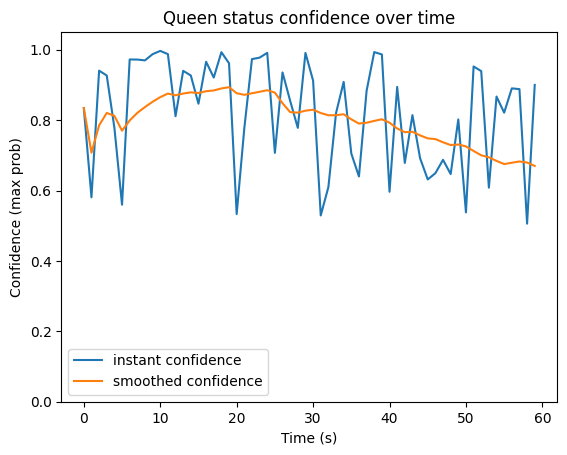

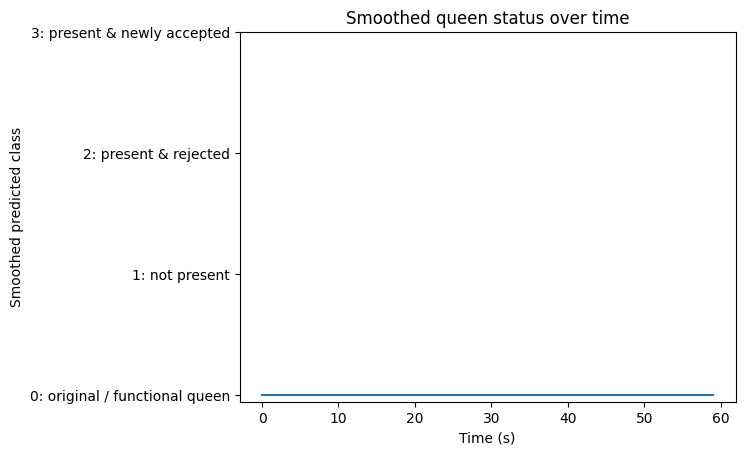

In [ ]:
times = np.array(times)
conf_inst = np.array(conf_inst)
conf_smooth = np.array(conf_smooth)
pred_smooth = np.array(pred_smooth)

plt.figure()
plt.plot(times, conf_inst, label="instant confidence")
plt.plot(times, conf_smooth, label="smoothed confidence")
plt.xlabel("Time (s)")
plt.ylabel("Confidence (max prob)")
plt.ylim(0, 1.05)
plt.legend()
plt.title("Queen status confidence over time")
plt.show()

plt.figure()
plt.plot(times, pred_smooth)
plt.yticks([0,1,2,3], [CLASS_NAME[i] for i in [0,1,2,3]])
plt.xlabel("Time (s)")
plt.ylabel("Smoothed predicted class")
plt.title("Smoothed queen status over time")
plt.show()

# Optional: minimal “phone opens browser” interface (JSON endpoint)

This is optional and clean for a thesis pitch: your “device” runs a local server, the phone reads it.

## Cell 7 — Start a tiny local JSON API (Flask)

In [ ]:
# pip install flask  (only if you don't have it)
from flask import Flask, jsonify
import threading

app = Flask(__name__)

# We’ll expose the latest smoothed prediction
STATE = {"t": None, "class": None, "confidence": None}

@app.get("/status")
def status():
    return jsonify(STATE)

def run_server():
    # host="0.0.0.0" makes it reachable from your phone on the same Wi-Fi
    app.run(host="0.0.0.0", port=8000, debug=False, use_reloader=False)

# Start server in background thread
threading.Thread(target=run_server, daemon=True).start()
print("Server running. Open http://<your-laptop-ip>:8000/status on your phone (same Wi-Fi).")

Then, inside your streaming loop (Cell 5), add/update this line after computing ```y_s, c_s```:

In [ ]:
STATE.update({"t": float(sec), "class": int(y_s), "confidence": float(c_s)})

That’s it: phone sees live JSON.